In [37]:
import numpy as np
import torch
from matplotlib import pyplot as plt
import torcwa
from tqdm.notebook import tqdm
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from Utils.utils import *

%load_ext line_profiler

# Hardware
# If GPU support TF32 tensor core, the matmul operation is faster than FP32 but with less precision.
# If you need accurate operation, you have to disable the flag below.
torch.backends.cuda.matmul.allow_tf32 = False
sim_dtype = torch.complex64
geo_dtype = torch.float32
device = torch.device('cuda')

# Simulation environment
# light
eps = 1e-12
inc_ang = -30.*(np.pi/180) + eps   # radian
azi_ang = 0.*(np.pi/180) + eps   # radian

pec_eps = torch.tensor(-10000.0 + 0.0j, dtype=sim_dtype, device=device)

order_N = 15
# geometry
h = 1000 #nm
grating_period = 1000 # nm
nx = 20000

x_plot = torch.linspace(0,grating_period,501,device=device)
z_plot = torch.linspace(-h,1.5*h,501,device=device)

wavelength = 600 + 1e-4
wavelengths = torch.linspace(300, 1100, 1601, dtype=float)+1e-4 # for stability

#Sanity check of staircase approximation
num_layers = 15
params = torch.tensor([[40,+np.pi/2]], dtype=geo_dtype, device=device)

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


## Testing and plotting

In [38]:
wavelengths

tensor([ 300.0001,  300.5001,  301.0001,  ..., 1099.0001, 1099.5001,
        1100.0001], dtype=torch.float64)

In [39]:
sim, sine_eps,A_film, A_grating,A_reflector, Reflectance, Transmittance, P_abs_film, P_abs_grating,P_abs_reflector, P_slices \
    = get_absorptance(params,wavelength,inc_ang,azi_ang,grating_period,h,order_N,n_layers=num_layers,nx=nx,add_reflector=True,reflector_type='pec',subpixel=True)

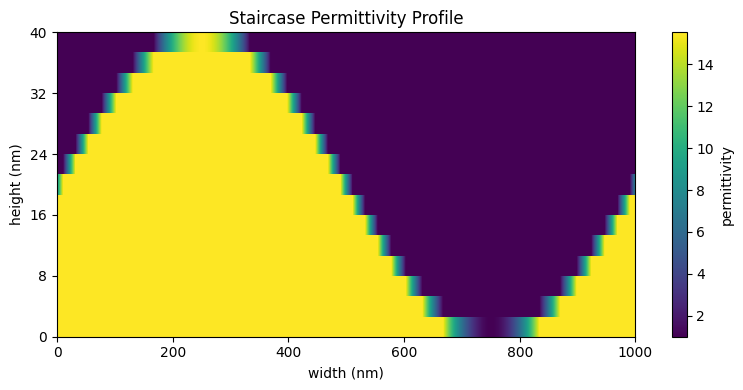

In [40]:
fig, ax = plt.subplots(figsize=(8, 4))
x_min_nm = x_plot.min().item()
x_max_nm = x_plot.max().item()
y_min_nm = 0.0
y_max_nm = float(sum(params[:,0]))

im = ax.imshow(
    sine_eps.cpu().abs().T,
    aspect='auto',
    origin='lower',
    cmap='viridis',
    interpolation='none',
    extent=[x_min_nm, x_max_nm, y_min_nm, y_max_nm],
)

ax.set_xticks(np.linspace(x_min_nm, x_max_nm, 6))
ax.set_yticks(np.linspace(y_min_nm, y_max_nm, 6))
ax.set_xlabel('width (nm)')
ax.set_ylabel('height (nm)')
ax.set_title('Staircase Permittivity Profile')
fig.colorbar(im, ax=ax, label='permittivity')
plt.tight_layout()
plt.show()

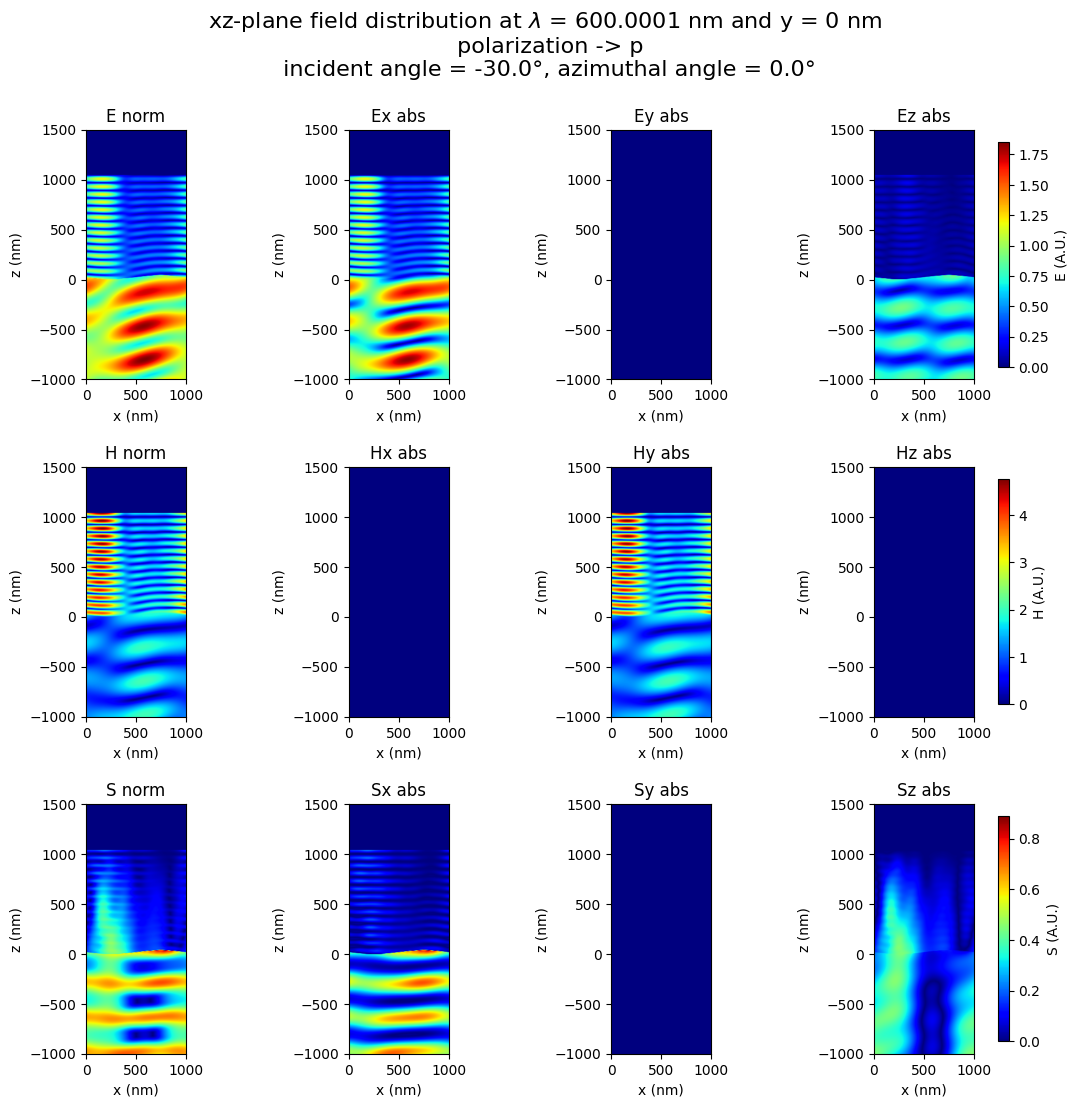

In [41]:
polarization = [1,0]
plot_fields(sim,x_plot,z_plot,wavelength,polarization,inc_ang,azi_ang)

In [42]:
A_film,A_grating,A_reflector

(tensor([0.4919, 0.4340], device='cuda:0', dtype=torch.float64),
 tensor([0.0118, 0.0102], device='cuda:0', dtype=torch.float64),
 tensor([-7.3885e-11,  1.1857e-10], device='cuda:0', dtype=torch.float64))

## Absorptance curves

### Num layers

In [188]:
layer_counts = [1, 5, 10, 20, 50, 100, 250]
simulation_results = {}

for num_layers in layer_counts:
    print(f'simulating absorptance curve for {num_layers} layers')
    absorptances = get_absorptance_curve(params,wavelengths,inc_ang,azi_ang,grating_period,h,order_N,\
        n_layers=num_layers,nx=nx,add_reflector=True,reflector_type='pec')

    simulation_results[num_layers] = {
        'absorptances': absorptances.cpu()
    }
    
# Save results to disk to decouple simulation from plotting
torch.save(simulation_results, '../Data/rcwa_convergence_data_num_layers.pt')

simulating absorptance curve for 1 layers


 29%|██▊       | 46/161 [00:01<00:04, 23.94it/s]


KeyboardInterrupt: 

In [ ]:
layer_counts = [1, 5, 10, 20, 50, 100, 250]
simulation_results = {}

for num_layers in layer_counts:
    print(f'simulating absorptance curve for {num_layers} layers')
    absorptances = get_absorptance_curve(params,wavelengths,inc_ang,azi_ang,grating_period,h,order_N,\
        n_layers=num_layers,nx=nx,add_reflector=True,reflector_type='pec',subpixel=False)

    simulation_results[num_layers] = {
        'absorptances': absorptances.cpu()
    }
    
# Save results to disk to decouple simulation from plotting
torch.save(simulation_results, '../Data/rcwa_convergence_data_num_layers_no_smoothing.pt')

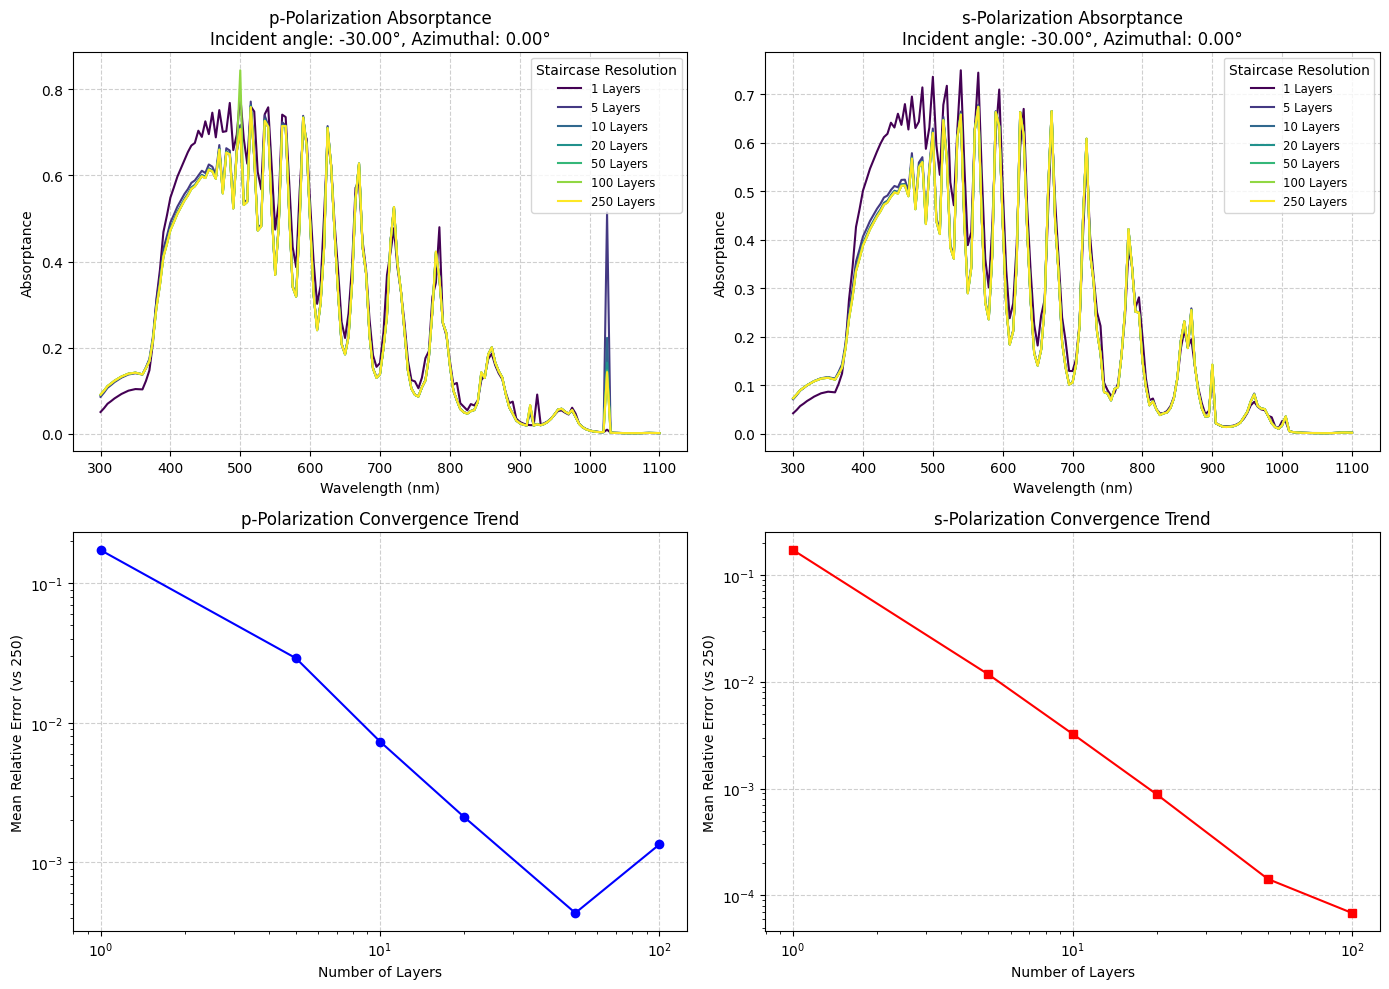

In [189]:
# Load the saved simulation data
results = torch.load('../Data/rcwa_convergence_data_num_layers.pt', weights_only=False)
layer_counts = sorted(list(results.keys()))

best_layer_count = layer_counts[-1]
best_abs = results[best_layer_count]['absorptances']

# Pre-calculate mean relative errors using torch functions to fix the TypeError
mean_errors_p = []
mean_errors_s = []
plot_layers = []

for num_layers in layer_counts:
    if num_layers == best_layer_count:
        continue
    curr_abs = results[num_layers]['absorptances']
    
    # Use torch functions instead of np functions on tensors
    err_p = torch.mean(torch.abs((curr_abs[:, 0] - best_abs[:, 0]) / (best_abs[:, 0] + 1e-12))).item()
    err_s = torch.mean(torch.abs((curr_abs[:, 1] - best_abs[:, 1]) / (best_abs[:, 1] + 1e-12))).item()
    
    mean_errors_p.append(err_p)
    mean_errors_s.append(err_s)
    plot_layers.append(num_layers)

# Create a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
(ax1_p, ax1_s), (ax2_p, ax2_s) = axs

colors = plt.cm.viridis(np.linspace(0, 1, len(layer_counts)))

for idx, num_layers in enumerate(layer_counts):
    curr_abs = results[num_layers]['absorptances']
    
    # Top Row: Plot spectra
    ax1_p.plot(wavelengths.cpu(), curr_abs[:, 0].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
    ax1_s.plot(wavelengths.cpu(), curr_abs[:, 1].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)

# Format Top Row (Absorptance Spectra)
ax1_p.set_xlabel('Wavelength (nm)')
ax1_p.set_ylabel('Absorptance')
ax1_p.set_title(f'p-Polarization Absorptance\nIncident angle: {inc_ang*180/np.pi:.2f}°, Azimuthal: {azi_ang*180/np.pi:.2f}°')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Staircase Resolution', loc='best', fontsize='small')
#ax1_p.set_yscale('log')

ax1_s.set_xlabel('Wavelength (nm)')
ax1_s.set_ylabel('Absorptance')
ax1_s.set_title(f's-Polarization Absorptance\nIncident angle: {inc_ang*180/np.pi:.2f}°, Azimuthal: {azi_ang*180/np.pi:.2f}°')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Staircase Resolution', loc='best', fontsize='small')
#ax1_s.set_yscale('log')

# Format Bottom Row (Mean Error Convergence)
ax2_p.plot(plot_layers, mean_errors_p, marker='o', linestyle='-', color='blue')
ax2_p.set_xlabel('Number of Layers')
ax2_p.set_ylabel(f'Mean Relative Error (vs {best_layer_count})')
ax2_p.set_title('p-Polarization Convergence Trend')
ax2_p.grid(True, linestyle='--', alpha=0.6)
ax2_p.set_yscale('log')
ax2_p.set_xscale('log')

ax2_s.plot(plot_layers, mean_errors_s, marker='s', linestyle='-', color='red')
ax2_s.set_xlabel('Number of Layers')
ax2_s.set_ylabel(f'Mean Relative Error (vs {best_layer_count})')
ax2_s.set_title('s-Polarization Convergence Trend')
ax2_s.grid(True, linestyle='--', alpha=0.6)
ax2_s.set_yscale('log')
ax2_s.set_xscale('log')

fig.tight_layout()
fig.savefig('../Data/Num_layer_convergence_fig')
plt.show()

### Fourier Order

In [190]:
Order_Ns = [1, 5, 10, 20, 40, 50, 100, 250]
simulation_results = {}
num_layers = 15

for order_N in Order_Ns:
    print(f'simulating absorptance curve for {order_N} fourier orders')
    absorptances = get_absorptance_curve(params,wavelengths,inc_ang,azi_ang,grating_period,h,order_N,\
        n_layers=num_layers,nx=nx,add_reflector=True,reflector_type='pec',subpixel=False)

    simulation_results[order_N] = {
        'absorptances': absorptances.cpu()
    }
    
# Save results to disk to decouple simulation from plotting
torch.save(simulation_results, '../Data/rcwa_convergence_data_order_N_no_smoothing.pt')

simulating absorptance curve for 1 fourier orders


100%|██████████| 161/161 [00:11<00:00, 13.58it/s]


simulating absorptance curve for 5 fourier orders


100%|██████████| 161/161 [00:13<00:00, 11.64it/s]


simulating absorptance curve for 10 fourier orders


...

simulating absorptance curve for 100 fourier orders


100%|██████████| 161/161 [04:42<00:00,  1.75s/it]


simulating absorptance curve for 250 fourier orders


 11%|█         | 18/161 [03:47<30:07, 12.64s/it]


KeyboardInterrupt: 

In [ ]:
# Load the saved simulation data
results = torch.load('../Data/rcwa_convergence_data_order_N.pt', weights_only=False)
order_Ns = sorted(list(results.keys()))

best_order = order_Ns[-1]
best_abs = results[best_order]['absorptances']

# Pre-calculate mean relative errors
mean_errors_p = []
mean_errors_s = []
plot_orders = []

for order_N in order_Ns:
    if order_N == best_order:
        continue
    curr_abs = results[order_N]['absorptances']
    
    # Calculate error relative to the highest Fourier order
    err_p = torch.mean(torch.abs((curr_abs[:, 0] - best_abs[:, 0]) / (best_abs[:, 0] + 1e-12))).item()
    err_s = torch.mean(torch.abs((curr_abs[:, 1] - best_abs[:, 1]) / (best_abs[:, 1] + 1e-12))).item()
    
    mean_errors_p.append(err_p)
    mean_errors_s.append(err_s)
    plot_orders.append(order_N)

# Create a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
(ax1_p, ax1_s), (ax2_p, ax2_s) = axs

colors = plt.cm.viridis(np.linspace(0, 1, len(order_Ns)))

for idx, order_N in enumerate(order_Ns):
    curr_abs = results[order_N]['absorptances']
    
    # Top Row: Plot spectra
    ax1_p.plot(wavelengths.cpu(), curr_abs[:, 0].cpu(), label=f'N = {order_N}', color=colors[idx], linewidth=1.5)
    ax1_s.plot(wavelengths.cpu(), curr_abs[:, 1].cpu(), label=f'N = {order_N}', color=colors[idx], linewidth=1.5)

# Format Top Row (Absorptance Spectra)
ax1_p.set_xlabel('Wavelength (nm)')
ax1_p.set_ylabel('Absorptance')
ax1_p.set_title(f'p-Polarization Absorptance\nIncident: {inc_ang*180/np.pi:.2f}°, Azimuthal: {azi_ang*180/np.pi:.2f}°')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Fourier Orders', loc='best', fontsize='small')
ax1_p.set_yscale('log')

ax1_s.set_xlabel('Wavelength (nm)')
ax1_s.set_ylabel('Absorptance')
ax1_s.set_title(f's-Polarization Absorptance\nIncident: {inc_ang*180/np.pi:.2f}°, Azimuthal: {azi_ang*180/np.pi:.2f}°')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Fourier Orders', loc='best', fontsize='small')
ax1_s.set_yscale('log')

# Format Bottom Row (Mean Error Convergence)
ax2_p.plot(plot_orders, mean_errors_p, marker='o', linestyle='-', color='blue')
ax2_p.set_xlabel('Number of Fourier Orders (N)')
ax2_p.set_ylabel(f'Mean Relative Error (vs N={best_order})')
ax2_p.set_title('p-Polarization Convergence Trend')
ax2_p.grid(True, linestyle='--', alpha=0.6)
ax2_p.set_yscale('log')
ax2_p.set_xscale('log')

ax2_s.plot(plot_orders, mean_errors_s, marker='s', linestyle='-', color='red')
ax2_s.set_xlabel('Number of Fourier Orders (N)')
ax2_s.set_ylabel(f'Mean Relative Error (vs N={best_order})')
ax2_s.set_title('s-Polarization Convergence Trend')
ax2_s.grid(True, linestyle='--', alpha=0.6)
ax2_s.set_yscale('log')
ax2_s.set_xscale('log')

fig.tight_layout()
fig.savefig('../Data/Order_N_convergence_no_smoothing_fig')
plt.show()